# Loading Dataset



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
dataset = pd.read_csv('')

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ac8b9edb85254016ea4a5fec65b4a10b0113736e0a1287069c206bbedcd8a8bc
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


# Pre-Processing

In [ ]:
dataset= dataset.drop(['Timestamp','Except for the above-mentioned factors, is there anything else that would affect your voting behavior?'], axis=1)

In [ ]:
dataset = dataset.dropna(subset=['In a few words, comment on what you think about the next election.'])
print(dataset['In a few words, comment on what you think about the next election.'].isnull().sum())
dataset.shape

0


(869, 35)

In [ ]:
new_column_names = {
    'What is your age?': 'Age',
    'What is your gender?': 'Gender',
    'Along with being a university student, do you have any other occupation?': 'Occupation',
    'Do you live with your family?': 'Reside with family',
    'Does your family live in their own house?  ': 'Own house',
    'What is your father’s educational background?': 'Father education',
    'What is your mother’s educational background?': 'Mother education',
    'How much time do you spend daily on social media? ': 'Time on socials',
    'In your opinion, is your family financially stable?': 'Financial stability',
    'Are your parents enthusiastic about voting?  ': 'Parent enthusiasm',
    'Have your family members voted in the most recent election?': "Family's recent vote",
    'How does your father represent voting to you?  ': 'Father vote representation',
    'How does your mother represent voting to you?  ': 'Mother vote representation',
    'Are any of your family members or someone close to you involved in politics?  ': 'Member in politics',
    'How does their involvement affect your voting behavior?': 'Effect of having political member',
    'How politically aware do you consider yourself?  ': 'Political awareness',
    'Have you ever voted before? If yes, how satisfied were you with the voting-experience?': 'Voting satisfaction',
    'How informed do you consider yourself about the parliamentary system of our country (both how it works and news related to it)?  ': 'Info about parliamentary system',
    'How informed do you consider yourself about the judicial system of our country (both how it works and news related to it)?  ': 'Info about judicial system',
    'How supportive are you about the notion of "Democracy"?': 'Supporting democratic notion',
    "Would you consider the 'newspaper' as a source of your news related to the country/ judicial system/ political system?": 'Newspaper',
    "Would you consider 'social media' as a source of your news related to the country/ judicial system/ political system?": 'Social media',
    "Would you consider 'television' as a source of your news related to the country/ judicial system/ political system?": 'Television',
    "Would you consider 'online news' as a source of your news related to the country/ judicial system/ political system?": 'Online news',
    'If the voting center is far away and you lack adequate transport, would you still be interested to go and vote?': 'Lack of transport/far',
    'If you get a day off on the day of election, would you participate in the election?   ': 'Day off',
    'If you have a very busy schedule or are busy with your personal affairs, would you participate in the election?': 'Busy schedule',
    'If there is pre-election violence, would you still go and vote?': 'Pre-election violence',
    'If there is violence on the day of election, would you still go and vote?': 'Election day violence',
    'Do you plan to vote where you are currently living or do you want to vote in your hometown?': 'Current city',
    'Were you eligible to vote in the most recent election?': 'Eligible in last election',
    'Did you vote in the most recent election?': 'Voted in last election',
    'Are you willing to vote in the immediate next election?': 'Label',
    'Do you think your vote will make a difference? ': 'Vote makes difference',
    'In a few words, comment on what you think about the next election.': 'Text'

}

dataset.rename(columns=new_column_names, inplace=True)


In [ ]:
target_column_name = 'Label'
ratio = dataset[target_column_name].value_counts(normalize=True)
print("Ratio of Yes to No:")
print(ratio)


Ratio of Yes to No:
Label
Yes    0.601841
No     0.398159
Name: proportion, dtype: float64


In [ ]:
column_mappings = {
    'Gender': {'Male': 0, 'Female': 1},
    'Reside with family': {'Yes': 1, 'No': 0},
    'Own house': {'No, they live in a rented house': 0, 'Yes': 1},
    'Financial stability': {'No': 0, 'Yes': 1},
    'Parent enthusiasm': {'No': 0, 'Yes': 1},
    "Family's recent vote": {'No': 0, 'Yes': 1},
    'Member in politics': {'No': 0, 'Yes': 1},
    'Newspaper': {'No': 0, 'Yes': 1},
    'Social media': {'No': 0, 'Yes': 1},
    'Television': {'No': 0, 'Yes': 1},
    'Online news': {'No': 0, 'Yes': 1},
    'Lack of transport/far': {'No': 0, 'Yes': 1},
    'Day off': {'No': 0, 'Yes': 1},
    'Busy schedule': {'No': 0, 'Yes': 1},
    'Pre-election violence': {'No': 0, 'Yes': 1},
    'Election day violence': {'No': 0, 'Yes': 1},
    'Current city': {'Hometown': 0, 'Current city': 1},
    'Eligible in last election': {'No': 0, 'Yes': 1},
    'Voted in last election': {'No': 0, 'Yes': 1},
    'Label': {'No': 0, 'Yes': 1},
    'Vote makes difference': {'No': 0, 'Yes': 1},
}

for column, mapping in column_mappings.items():
    dataset[column] = dataset[column].map(mapping)


In [ ]:
multivariable_columns_to_encode = [ 'Occupation', 'Father education', 'Mother education',
       'Time on socials', 'Father vote representation',
       'Mother vote representation', 'Effect of having political member',
       'Political awareness', 'Voting satisfaction',
       'Info about parliamentary system', 'Info about judicial system',
       'Supporting democratic notion']


multivariable_encoded_df = pd.DataFrame()

for col in multivariable_columns_to_encode:
    dummies = pd.get_dummies(dataset[col], prefix=col, drop_first=True)
    dummies = dummies.astype(int)
    multivariable_encoded_df = pd.concat([multivariable_encoded_df, dummies], axis=1)


df = pd.concat([dataset, multivariable_encoded_df], axis=1)

In [ ]:
df = df.drop(['Occupation', 'Father education', 'Mother education',
       'Time on socials', 'Father vote representation',
       'Mother vote representation', 'Effect of having political member',
       'Political awareness', 'Voting satisfaction',
       'Info about parliamentary system', 'Info about judicial system',
       'Supporting democratic notion'], axis = 'columns')

In [ ]:
def label_age(age):
    if age >= 19 and age <= 21:
        return 'Age1'
    elif age >= 22 and age <= 23:
        return 'Age2'
    elif age > 23:
        return 'Age3'

df['Age'] = df['Age'].apply(label_age)


In [ ]:
age_columns_to_encode = [ 'Age']

age_encoded_df = pd.DataFrame()

for col in age_columns_to_encode:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    dummies = dummies.astype(int)
    age_encoded_df = pd.concat([age_encoded_df, dummies], axis=1)

df = pd.concat([df, age_encoded_df], axis=1)

In [ ]:
df = df.drop(['Age'], axis = 'columns')

In [ ]:
df_shuffled = df.sample(frac=1, random_state=42)

df_shuffled.reset_index(drop=True, inplace=True)

In [ ]:
df_shuffled['Text']= df_shuffled['Text'].fillna('')

# Creating numerical and text datasets

In [ ]:
df_text = df_shuffled[['Text','Label']]
df_text

,Text,Label
0,I do not think anything.,0
1,If election happens!,1
2,Nothing,1
3,It will be fair and democratic as always and m...,1
4,Nothing,0
...,...,...
864,No comments,1
865,The next election is expected to be free and f...,1
866,No,1
867,Nothing especial,0


In [ ]:
df_num = df_shuffled.drop(['Text'], axis = 'columns')
df_num

,Gender,Reside with family,Own house,Financial stability,Parent enthusiasm,Family's recent vote,Member in politics,Newspaper,Social media,Television,...,Voting satisfaction_Moderately satisfied,Voting satisfaction_Never voted before,Info about parliamentary system_Not at all informed,Info about parliamentary system_Strongly informed,Info about judicial system_Not at all informed,Info about judicial system_Strongly informed,Supporting democratic notion_Moderately supportive,Supporting democratic notion_Not supportive,Age_Age2,Age_Age3
0,0,1,1,1,0,1,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,1,1,0,0,0,1,0,0,...,1,0,1,0,0,0,1,0,1,0
2,1,1,1,1,1,1,0,1,1,0,...,1,0,1,0,0,0,0,0,0,0
3,0,1,1,1,1,1,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
4,1,1,1,1,0,0,0,1,1,1,...,0,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,0,1,1,0,1,1,0,1,0,1,...,1,0,0,0,0,0,1,0,0,0
865,0,0,0,1,0,0,0,0,1,0,...,0,1,0,1,0,1,0,0,1,0
866,0,1,0,1,1,1,0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
867,0,1,1,1,0,0,0,0,1,0,...,0,1,1,0,1,0,0,0,0,0


# Train-test-split

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Assuming the last column is the target variable
X_num = df_num.drop(['Label'], axis=1)
y_num = df_num['Label']

# Split the data into training and testing sets with stratification
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y_num, test_size=0.2, random_state=42, stratify=y_num)


# MLP

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


smote = SMOTE(random_state=42)

X_train_num_resampled, y_train_num_resampled = smote.fit_resample(X_train_num, y_train_num)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Calculate the number of neurons in the hidden layer
num_neurons_input = X_train_num_resampled.shape[1]
num_neurons_output = 1
num_neurons_hidden = 35

# Define the model with one hidden layer and dropout
model_1_oversampled = Sequential([
    Input(shape=(num_neurons_input,)),
    Dropout(0.4),
    Dense(num_neurons_hidden, activation='relu'),
    Dropout(0.4),
    Dense(num_neurons_output, activation='sigmoid')
])

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss_function = 'binary_crossentropy'
model_1_oversampled.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

# Train the model
version_1_oversampled = model_1_oversampled.fit(X_train_num_resampled, y_train_num_resampled, epochs=300, batch_size=50, validation_data=(X_test_num, y_test_num))

# Evaluate the model on the test set
test_loss_o, test_accuracy_o = model_1_oversampled.evaluate(X_test_num, y_test_num)
print()
print("MLP using oversampled training data:")
print("Neurons in input layer:", num_neurons_input)
print("Neurons in output layer:", num_neurons_output)
print("Neurons in hidden layer:", num_neurons_hidden)
print("Number of hidden layers: 1")
print("Test Loss:", test_loss_o)
print("Test Accuracy:", test_accuracy_o)


Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.4989 - loss: 0.7891 - val_accuracy: 0.6207 - val_loss: 0.6619
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5376 - loss: 0.7115 - val_accuracy: 0.7241 - val_loss: 0.6034
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5873 - loss: 0.6797 - val_accuracy: 0.7586 - val_loss: 0.5788
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6342 - loss: 0.6265 - val_accuracy: 0.7989 - val_loss: 0.5602
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6260 - loss: 0.6228 - val_accuracy: 0.7759 - val_loss: 0.5465
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6655 - loss: 0.6055 - val_accuracy: 0.7874 - val_loss: 0.5355
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6595 - loss: 0.6190 - val_accuracy: 0.7874 - val_loss: 0.5226
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6649 - loss: 0.6076 - val_accuracy: 0.

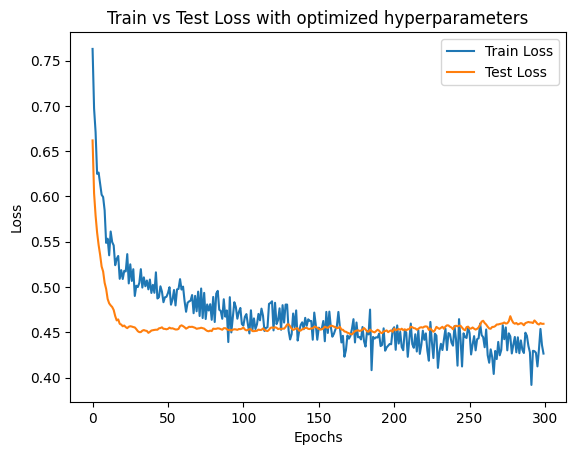

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Precision: 0.8073394495412844
Recall: 0.8380952380952381
F1-score: 0.822429906542056


In [ ]:
import matplotlib.pyplot as plt

# Plot train vs test loss
plt.plot(version_1_oversampled.history['loss'], label='Train Loss')
plt.plot(version_1_oversampled.history['val_loss'], label='Test Loss')
plt.title('Train vs Test Loss with optimized hyperparameters')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions on the test set
y_pred = np.round(model_1_oversampled.predict(X_test_num))

# Calculate precision, recall, and F1-score
precision = precision_score(y_test_num, y_pred)
recall = recall_score(y_test_num, y_pred)
f1 = f1_score(y_test_num, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


# Sentiment analysis {XGBoost}

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer



corpus = []
for i in range(0, len(df_text)):

  review = str(df_text['Text'][i])
  review = re.sub('[^a-zA-Z]', ' ', review)
  review = review.lower()
  review = review.split()
  ps = PorterStemmer()
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]
  review = ' '.join(review)
  corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=750)
X = tfidf.fit_transform(corpus).toarray()

In [ ]:
y = df_text.iloc[:, 1].values

In [ ]:
X.shape

(869, 750)

In [ ]:
y.shape

(869,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=42)

X_train_text_resampled, y_train_text_resampled = smote.fit_resample(X_train_text, y_train_text)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Instantiate the model with the best parameters

xgb_best = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.2,
    max_depth=7,
    n_estimators=57,
    subsample=1.0,
    random_state=42
)

# Train the model on the training data
xgb_best.fit(X_train_text_resampled, y_train_text_resampled)

# Make predictions on the test set
y_pred_best = xgb_best.predict(X_test_text)

# Evaluate the model
accuracy_best = accuracy_score(y_test_text, y_pred_best)
print(f'Accuracy of XGBoost: {accuracy_best}')


Accuracy of XGBoost: 0.6206896551724138


# Ensemble model

In [ ]:
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.optimizers import Adam


y_pred_xgb_prob = xgb_best.predict_proba(X_test_text)[:, 1]  # Probability for class 1
y_pred_xgb_prob = np.expand_dims(y_pred_xgb_prob, axis = -1)   # Reshaping for concatenation

y_pred_mlp_prob = model_1_oversampled.predict(X_test_num)
y_pred_mlp_prob = np.expand_dims(y_pred_mlp_prob, axis=-1)   # Reshaping for concatenation

# Defining the input layers for XGBoost and MLP probabilities
input_xgb = Input(shape=(1,), name="xgb_input")
input_mlp = Input(shape=(1,), name="mlp_input")

# Concatenating the inputs
merged = Concatenate()([input_xgb, input_mlp])

# Adding a single hidden layer with 35 neurons
hidden_layer = Dense(35, activation='relu', name="hidden_layer")(merged)

# Final output layer
output = Dense(1, activation='sigmoid', name="final_output")(hidden_layer)

# Defining the model with all layers
ensemble_model = Model(inputs=[input_xgb, input_mlp], outputs=output)

# Compiling the model
optimizer = Adam(learning_rate=0.001)
ensemble_model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

# Displaying model structure
ensemble_model.summary()

y_train_combined = y_test_text
ensemble_model.fit([y_pred_xgb_prob, y_pred_mlp_prob], y_train_combined, epochs=300, batch_size=50)


y_pred_ensemble = ensemble_model.predict([y_pred_xgb_prob, y_pred_mlp_prob])
y_pred_ensemble_final = (y_pred_ensemble > 0.5).astype(int)  # Converting to binary

final_accuracy = accuracy_score(y_test_text, y_pred_ensemble_final)
print(f'Ensemble Model Accuracy: {final_accuracy}')


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ xgb_input (InputLayer)    │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mlp_input (InputLayer)    │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 2)              │              0 │ xgb_input[0][0],       │
│                           │                        │                │ mlp_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ hidden_layer (Dense)      │ (None, 35)             │            105 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ final_output (Dense)      │ (None, 1)              │             36 │ hidden_layer[0][0]     │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3640 - loss: 0.7326  
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3883 - loss: 0.7224 
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 0.7152 
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3450 - loss: 0.7089 
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3843 - loss: 0.7031 
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3777 - loss: 0.6980 
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4489 - loss: 0.6924 
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6014 - loss: 0.6862 
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6127 - loss: 0.6822 
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5840 - loss: 0.6781 
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6014 - loss: 0.6726 
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5854 - lo

In [ ]:
y_pred_ensemble_final.shape

(174, 1)

# Creating separate datasets of WILL VOTE & WILL NOT VOTE from the predictions of MLP

In [ ]:
predictions = model_1_oversampled.predict(X_test_num)
binary_predictions = (predictions >= 0.5).astype(int)

X_test_num_will_not_vote = X_test_num[binary_predictions.flatten() == 0]
predictions_will_not_vote = predictions[binary_predictions.flatten() == 0]

combined_dataset_will_not_vote = X_test_num_will_not_vote.copy()
combined_dataset_will_not_vote['Predictions'] = predictions_will_not_vote

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
predictions = model_1_oversampled.predict(X_test_num)
binary_predictions = (predictions >= 0.5).astype(int)

X_test_num_will_vote = X_test_num[binary_predictions.flatten() == 1]
predictions_will_vote = predictions[binary_predictions.flatten() == 1]

combined_dataset_will_vote = X_test_num_will_vote.copy()
combined_dataset_will_vote['Predictions'] = predictions_will_vote


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


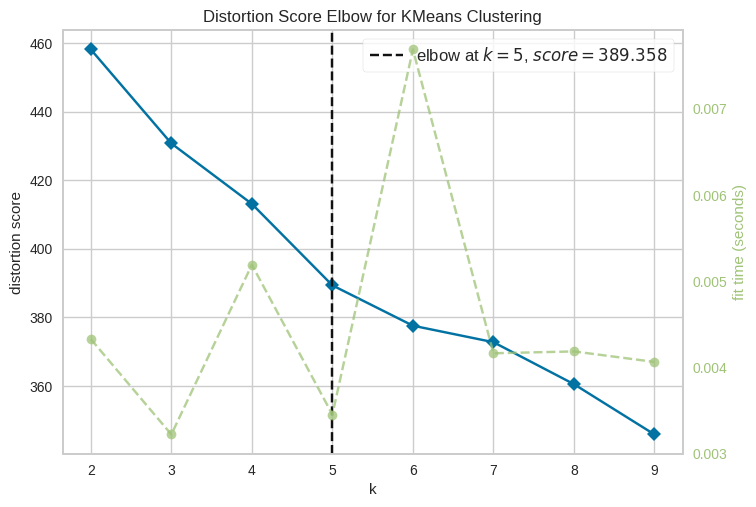

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

X = combined_dataset_will_not_vote.drop(['Predictions'], axis=1)
y = combined_dataset_will_not_vote['Predictions']

km = KMeans(random_state=0)
visualizer = KElbowVisualizer(km, k=(2,10))

visualizer.fit(X)
visualizer.show()

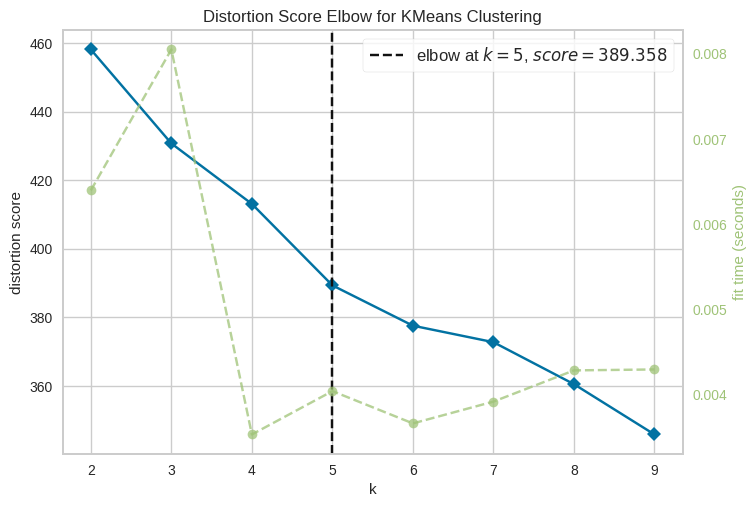

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

X1 = combined_dataset_will_vote.drop(['Predictions'], axis=1)
y1 = combined_dataset_will_vote['Predictions']

km1 = KMeans(random_state=0)
visualizer1 = KElbowVisualizer(km1, k=(2,10))

visualizer1.fit(X)
visualizer1.show()

# Individual Clusters

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


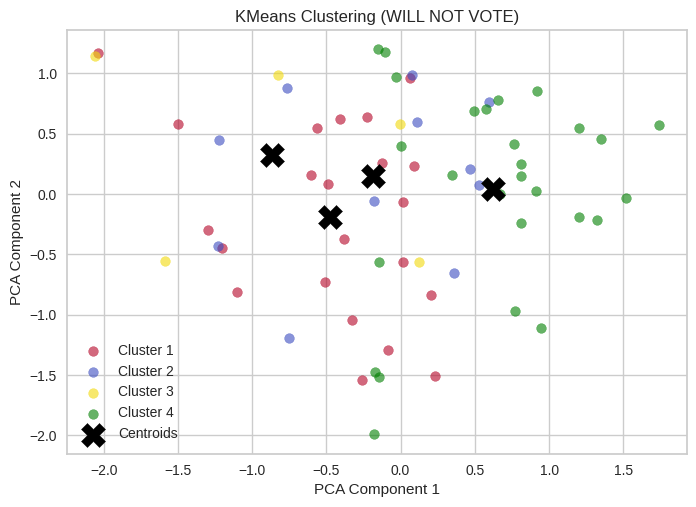

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Preparing the dataset
X = combined_dataset_will_not_vote.drop(['Predictions'], axis=1)
y = combined_dataset_will_not_vote['Predictions']

# Fitting KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Transforming centroids to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plotting
colors = ['#b40426', '#3b4cc0', '#f2da0a', '#008000']
for i in range(4):
    cluster_points = X_pca[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f"Cluster {i+1}", alpha=0.6)

# Plotting centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=300, label='Centroids')

# Labeling
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering (WILL NOT VOTE)")
plt.legend()
plt.show()

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np


X = combined_dataset_will_not_vote.drop(['Predictions'], axis=1)
y = combined_dataset_will_not_vote['Predictions']
# LIME Explainer setup
predictions_clusters_will_not_vote = kmeans.predict(X)
feature_names = X.columns.tolist()

explainer = LimeTabularExplainer(
    training_data= X.values,
    mode="classification",
    training_labels= y,
    feature_names=feature_names,
    class_names=["Will not vote", "Will vote"],
    discretize_continuous=False
)
#===============================================================================
def predict_fn(x):

    probabilities = []
    for sample in x:
        # Finding the closest row in X_test_num_will_not_vote to the current sample
        distances = np.sum((X_test_num_will_not_vote.values - sample)**2, axis=1)
        closest_row_index = np.argmin(distances)

        # Getting the probabilities from the closest row
        probabilities.append(
            [
                1 - X_test_num_will_not_vote.iloc[closest_row_index, 0],  # Probability for class 0
                X_test_num_will_not_vote.iloc[closest_row_index, 0]   # Probability for class 1
            ]
        )
    return np.array(probabilities)
#===============================================================================

explanation_data = []
optimal_k_will_not_vote = 4

#===============================================================================
for cluster in range(optimal_k_will_not_vote):
    #print(f"\nExplaining Centroid of Cluster {cluster + 1}")


    centroid = kmeans.cluster_centers_[cluster]

    explanation = explainer.explain_instance(
        centroid,
        predict_fn,
        num_features=len(feature_names)
    )

    # Collecting explanations for the centroid
    exp_list = explanation.as_list()

    for feature, weight in exp_list:
        explanation_data.append([
            cluster + 1,  # Cluster Number
            f"Cluster {cluster + 1} Centroid",  # Labelling as "Centroid"
            feature,
            weight
        ])

#===============================================================================

for cluster in range(optimal_k_will_not_vote):
    #print(f"\nExplaining samples in Cluster {cluster + 1}")

    cluster_samples = X.values[predictions_clusters_will_not_vote == cluster]

    for i, sample in enumerate(cluster_samples):

        explanation = explainer.explain_instance(
            sample,
            predict_fn,
            num_features=len(feature_names)
        )

        exp_list = explanation.as_list()

        sample_label = i + 1

        for feature, weight in exp_list:
            explanation_data.append([cluster + 1, sample_label , feature, weight])
#===============================================================================

explanation_df_will_not_vote = pd.DataFrame(
    explanation_data, columns=["Cluster", "Sample", "Feature", "Weight"]
)
pivoted_df_will_not_vote = explanation_df_will_not_vote.pivot_table(
    index=["Cluster", "Sample"], columns="Feature", values="Weight"
)
#===============================================================================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pivoted_df_will_not_vote

Feature                     Age_Age2  Age_Age3  Busy schedule  Current city  \
Cluster Sample                                                                
1       1                  -0.013583  0.004098      -0.004706      0.059955   
        2                  -0.002118 -0.003753      -0.001959      0.059624   
        3                  -0.002638  0.002445      -0.000031      0.077833   
        4                   0.002358 -0.000677      -0.001064      0.065006   
        5                   0.001073  0.009166       0.002637      0.074492   
        6                   0.002970  0.003620       0.001328      0.063523   
        7                   0.003976 -0.004468      -0.002592      0.068764   
        8                  -0.010075  0.004105       0.002375      0.071286   
        9                   0.004512  0.007381      -0.005000      0.068458   
        10                  0.005009 -0.002954       0.000957      0.058019   
        11                 -0.008551 -0.000287       0.000538      0.063628   
        12                  0.001622 -0.004725       0.000357      0.057934   
        13                 -0.005182  0.018232       0.001570      0.052765   
        14                 -0.001394  0.010173      -0.003369      0.058131   
        15                 -0.004726 -0.003817       0.004535      0.060764   
        16                 -0.003180  0.002758      -0.002594      0.068120   
        17                 -0.005074  0.000796       0.004149      0.060833   
        18                  0.001286 -0.001785      -0.000465      0.061373   
        19                 -0.010210 -0.006862      -0.000490      0.066357   
        20                 -0.003716  0.007057       0.002923      0.064248   
        21                 -0.006608 -0.008818       0.000292      0.060047   
        22                 -0.012739  0.002237       0.004308      0.056337   
        Cluster 1 Centroid  0.002652 -0.004446       0.002541      0.069690   
2       1                   0.001425  0.002925      -0.005369      0.061901   
        2                  -0.003337  0.003094       0.000872      0.063190   
        3                   0.005086  0.004897      -0.002385      0.063964   
        4                  -0.004803  0.001252       0.001845      0.063402   
        5                  -0.009152 -0.000637      -0.001342      0.066867   
        6                   0.006971 -0.005150       0.001717      0.061924   
        7                  -0.008284 -0.001169       0.007579      0.064920   
        8                  -0.003456 -0.001274      -0.002729      0.064470   
        9                  -0.004381 -0.003457      -0.000969      0.069141   
        10                 -0.013142  0.000560       0.002481      0.068589   
        11                 -0.001732  0.012457      -0.009069      0.067238   
        Cluster 2 Centroid -0.002602 -0.003817       0.004316      0.061720   
3       1                  -0.003770  0.002487       0.004879      0.064844   
        2                  -0.009714 -0.004605      -0.011056      0.068581   
        3                  -0.000198 -0.003542       0.000683      0.075155   
        4                  -0.005074 -0.004844       0.012783      0.071619   
        5                  -0.005305  0.008534       0.011731      0.050541   
        Cluster 3 Centroid  0.005629  0.001467      -0.004231      0.069802   
4       1                  -0.011530  0.000974      -0.008878      0.065301   
        2                  -0.008878  0.006114       0.000196      0.071525   
        3                  -0.012704  0.001329       0.005905      0.073506   
        4                   0.008027 -0.001428       0.001717      0.063243   
        5                  -0.005919  0.010231       0.001960      0.066221   
        6                  -0.005349  0.002683      -0.008914      0.062409   
        7                  -0.004808  0.006928       0.004308      0.064278   
        8                   0.003270  0.006415    

In [ ]:
#output_file = '/content/drive/MyDrive/Thesis Related Works/Folder for FINAL THESIS/Code/Final code/will_not_vote_limepreds.xlsx'
#pivoted_df_will_not_vote.to_excel(output_file, index=True)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


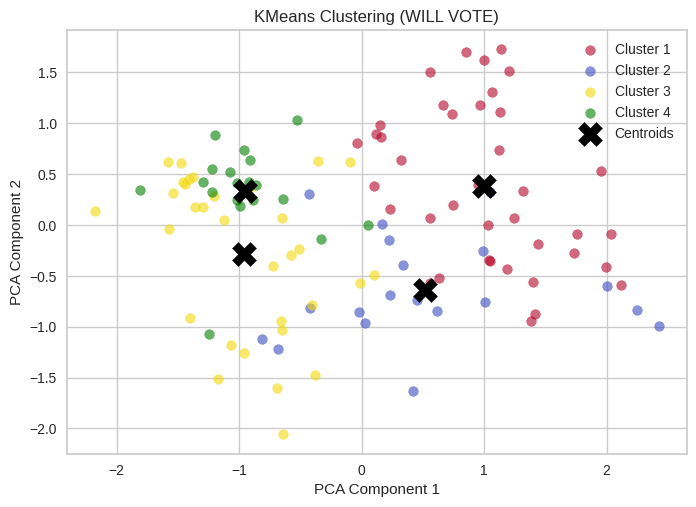

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Preparing the dataset
X = combined_dataset_will_vote.drop(['Predictions'], axis=1)
y = combined_dataset_will_vote['Predictions']

# Fitting KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Transforming centroids to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plotting
colors = ['#b40426', '#3b4cc0', '#f2da0a', '#008000']
for i in range(4):
    cluster_points = X_pca[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f"Cluster {i+1}", alpha=0.6)

# Plotting centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=300, label='Centroids')

# Labeling
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering (WILL VOTE)")
plt.legend()
plt.show()

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np


X = combined_dataset_will_vote.drop(['Predictions'], axis=1)
y = combined_dataset_will_vote['Predictions']
# LIME Explainer setup
predictions_clusters_will_vote = kmeans.predict(X)
feature_names = X.columns.tolist()

explainer = LimeTabularExplainer(
    training_data= X.values,
    mode="classification",
    training_labels= y,
    feature_names=feature_names,
    class_names=["Will vote", "Will not vote"],
    discretize_continuous=False
)
#===============================================================================
def predict_fn(x):

    probabilities = []
    for sample in x:
        # Finding the closest row in X_test_1_will_not_vote to the current sample
        distances = np.sum((X_test_num_will_vote.values - sample)**2, axis=1)
        closest_row_index = np.argmin(distances)

        # Getting the probabilities from the closest row
        probabilities.append(
            [
                X_test_num_will_vote.iloc[closest_row_index, 0],   # Probability for class 1
                1 - X_test_num_will_vote.iloc[closest_row_index, 0]  # Probability for class 0
            ]
        )
    return np.array(probabilities)
#===============================================================================

explanation_data = []
optimal_k_will_vote = 4

#===============================================================================
for cluster in range(optimal_k_will_vote):
    #print(f"\nExplaining Centroid of Cluster {cluster + 1}")


    centroid = kmeans.cluster_centers_[cluster]

    explanation = explainer.explain_instance(
        centroid,
        predict_fn,
        num_features=len(feature_names)
    )

    # Collecting explanations for the centroid
    exp_list = explanation.as_list()

    for feature, weight in exp_list:
        explanation_data.append([
            cluster + 1,  # Cluster Number
            f"Cluster {cluster + 1} Centroid",  # Labelling as "Centroid"
            feature,
            weight
        ])

#===============================================================================

for cluster in range(optimal_k_will_vote):
    #print(f"\nExplaining samples in Cluster {cluster + 1}")

    cluster_samples = X.values[predictions_clusters_will_vote == cluster]

    for i, sample in enumerate(cluster_samples):

        explanation = explainer.explain_instance(
            sample,
            predict_fn,
            num_features=len(feature_names)
        )

        exp_list = explanation.as_list()

        sample_label = i + 1

        for feature, weight in exp_list:
            explanation_data.append([cluster + 1, sample_label , feature, weight])
#===============================================================================

explanation_df_will_vote = pd.DataFrame(
    explanation_data, columns=["Cluster", "Sample", "Feature", "Weight"]
)
pivoted_df_will_vote = explanation_df_will_vote.pivot_table(
    index=["Cluster", "Sample"], columns="Feature", values="Weight"
)
#===============================================================================
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pivoted_df_will_vote

Feature                     Age_Age2  Age_Age3  Busy schedule  Current city  \
Cluster Sample                                                                
1       1                  -0.011121 -0.003263      -0.010595     -0.021221   
        2                  -0.004612  0.013380      -0.016407     -0.022488   
        3                  -0.014999 -0.004368      -0.020818     -0.008938   
        4                   0.005168  0.007810      -0.011476     -0.016187   
        5                  -0.006415 -0.001806      -0.022643     -0.015040   
        6                   0.001971  0.009544      -0.020471     -0.018963   
        7                  -0.000966  0.007649      -0.025986     -0.021354   
        8                  -0.009065  0.000603      -0.012846     -0.012033   
        9                  -0.005636  0.012338      -0.003631     -0.026427   
        10                 -0.001786  0.008657      -0.013525     -0.019989   
        11                 -0.003083  0.000606      -0.012815     -0.013260   
        12                  0.006050  0.005235      -0.015124     -0.014747   
        13                 -0.002679  0.007335      -0.015574     -0.023567   
        14                 -0.011242  0.004727      -0.017736     -0.015014   
        15                  0.001660 -0.000298      -0.011945     -0.014297   
        16                  0.003650 -0.004278      -0.018307     -0.018126   
        17                 -0.010483  0.003032      -0.018547     -0.019516   
        18                 -0.010208  0.011324      -0.027968     -0.020987   
        19                 -0.008686  0.002444      -0.017621     -0.015247   
        20                 -0.010170 -0.003520      -0.023838     -0.027811   
        21                  0.004791  0.012102      -0.022575     -0.024930   
        22                  0.009043  0.014941      -0.009635     -0.029112   
        23                 -0.003737 -0.004764      -0.008600     -0.017311   
        24                 -0.004046  0.010246      -0.016262     -0.020267   
        25                 -0.002930  0.008211      -0.025904     -0.024326   
        26                  0.006948 -0.010963      -0.005594     -0.022641   
        27                  0.001095  0.001548      -0.003639     -0.028649   
        28                 -0.003643  0.000049      -0.014571     -0.008800   
        29                 -0.011683  0.002820      -0.023184     -0.020787   
        30                 -0.021946  0.013461      -0.023583     -0.016297   
        31                 -0.002134  0.009631      -0.012858     -0.018006   
        32                 -0.002717  0.001097      -0.015930     -0.010687   
        33                 -0.003546 -0.004077      -0.016802     -0.019277   
        34                 -0.009908  0.005812      -0.015522     -0.014261   
        35                 -0.009951  0.006591      -0.015668     -0.021803   
        36                 -0.003849  0.005821      -0.021958     -0.027161   
        37                  0.000812 -0.003427      -0.006339     -0.016323   
        38                 -0.015565  0.003017      -0.010389     -0.027811   
        39                  0.002319  0.006064      -0.015962     -0.010996   
        Cluster 1 Centroid -0.011162  0.001456      -0.025586     -0.018022   
2       1                   0.009462 -0.013452      -0.009303     -0.021804   
        2                  -0.005503  0.010087      -0.014100     -0.019610   
        3                  -0.006368  0.009080      -0.009093     -0.025596   
        4                   0.004321  0.015402      -0.016097     -0.014258   
        5                   0.000868 -0.004209      -0.012357     -0.014378   
        6                  -0.002824  0.001355      -0.013710     -0.026978   
        7                  -0.005608  0.014024      -0.007790     -0.022216   
        8                  -0.004260  0.002531      -0.011472     -0.032475   
        9                  -0.004399  0.009281    

In [ ]:
#output_file = '/content/drive/MyDrive/Thesis Related Works/Folder for FINAL THESIS/Code/Final code/will_vote_limepreds.xlsx'
#pivoted_df_will_vote.to_excel(output_file, index=True)

# Correlation of MLP predictions

In [ ]:
# Get predictions from the model
predictions = model_1_oversampled.predict(X_test_num)
binary_predictions = (predictions >= 0.5).astype(int)  # Convert to binary predictions (0 or 1)

# Create a DataFrame with predictions and features
prediction_df = X_test_num.copy()  # Start with the features
prediction_df['Prediction'] = binary_predictions  # Add the predictions column

# Display the DataFrame
display(prediction_df)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Gender,Reside with family,Own house,Financial stability,Parent enthusiasm,Family's recent vote,Member in politics,Newspaper,Social media,Television,Online news,Lack of transport/far,Day off,Busy schedule,Pre-election violence,Election day violence,Current city,Eligible in last election,Voted in last election,Vote makes difference,Occupation_Monthly salaried worker,Occupation_No,Occupation_Own a business,Father education_HSC / A levels,Father education_Masters / PhD,Father education_Primary School,Father education_SSC / O levels,Mother education_HSC / A levels,Mother education_Masters / PhD,Mother education_Primary School,Mother education_SSC / O levels,Time on socials_<1 hour,Time on socials_>3 hours,Time on socials_I don't use social media,Father vote representation_Encourages you to vote,Father vote representation_Neutral,Mother vote representation_Encourages you to vote,Mother vote representation_Neutral,Effect of having political member_Their involvement has made me disinterested in voting,Effect of having political member_Their involvement moderately influences me to vote,Effect of having political member_Their involvement strongly influences me to vote,Political awareness_Not at all aware,Political awareness_Strongly aware,Voting satisfaction_Highly unsatisfied,Voting satisfaction_Moderately satisfied,Voting satisfaction_Never voted before,Info about parliamentary system_Not at all informed,Info about parliamentary system_Strongly informed,Info about judicial system_Not at all informed,Info about judicial system_Strongly informed,Supporting democratic notion_Moderately supportive,Supporting democratic notion_Not supportive,Age_Age2,Age_Age3,Prediction
489,0,1,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0
301,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,1,0,1,0,0,0,0
636,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,0
634,0,1,1,1,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0
385,0,0,1,1,1,1,0,1,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
590,0,1,1,1,0,0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
223,0,1,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0
386,0,1,1,0,0,0,1,1,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,1,0,1
300,0,0,1,1,1,1,0,1,0,1,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1
603,0,1,0,1,0,1,0,1,0,1,1,1,1,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1


In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Calculate Spearman correlations
correlations = {}
for column in prediction_df.columns:
    if column != 'Prediction':  # Avoid self-correlation
        corr, _ = spearmanr(prediction_df['Prediction'], prediction_df[column])
        correlations[column] = corr

# Convert the results into a DataFrame
correlation_table = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation with Prediction'])

# Sort by absolute correlation value
correlation_table['Absolute Correlation'] = correlation_table['Correlation with Prediction'].abs()
correlation_table = correlation_table.sort_values(by='Absolute Correlation', ascending=False)

# Reset the index and rename it to 'Feature'
correlation_table = correlation_table.reset_index().rename(columns={'index': 'Feature'})

# Drop the temporary 'Absolute Correlation' column
correlation_table = correlation_table.drop('Absolute Correlation', axis=1)

# Display the table
pd.options.display.max_colwidth = None
display(correlation_table)


,Feature,Correlation with Prediction
0,Day off,0.717881
1,Parent enthusiasm,0.512755
2,Vote makes difference,0.485266
3,Lack of transport/far,0.459453
4,Busy schedule,0.409052
5,Father vote representation_Encourages you to vote,0.402546
6,Mother vote representation_Encourages you to vote,0.389506
7,Family's recent vote,0.355039
8,Pre-election violence,0.343244
9,Father vote representation_Neutral,-0.334564


# LIME on MLP predictions

In [ ]:
import lime
import lime.lime_tabular

# Creating LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_num.values,
    feature_names=X_train_num_resampled.columns.values.tolist(),
    class_names=['Not voting', 'Voting'],  # Adjusting based on our class labels
    mode='classification',
    verbose=True,
    discretize_continuous=False
)

# Defining predict function for LIME, ensuring it returns probabilities for each class
def predict_fn(x):
    # Get raw predictions from our model
    raw_predictions = model_1_oversampled.predict(x)

    # Ensuring raw_predictions is 2D, even if the model only has one output node
    probabilities = np.stack([1 - raw_predictions.ravel(), raw_predictions.ravel()], axis=-1)

    return probabilities


all_explanations = []

# Looping through each instance in X_test_num
for i in range(X_test_num.shape[0]):
    exp = explainer.explain_instance(X_test_num.values[i], predict_fn, num_features=X_test_num.shape[1])
    all_explanations.extend(exp.as_list())

# Creating a DataFrame from the explanations
explanation_df = pd.DataFrame(all_explanations, columns=['Feature', 'Weight'])

# Adding an 'Instance' column to identify which instance the explanation belongs to
explanation_df['Instance'] = explanation_df.index // X_test_num.shape[1]


# Displaying the DataFrame
explanation_df

pivoted_df = explanation_df.pivot_table(
    index=["Instance"], columns="Feature", values="Weight"
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pivoted_df

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6086720735597675
Prediction_local [0.09097146]
Right: 0.07816301
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6097440020958735
Prediction_local [0.28338156]
Right: 0.12557657
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6094888626787325
Prediction_local [0.30296176]
Right: 0.3270398
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6099840279873552
Prediction_local [0.26115095]
Right: 0.17527482
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.608357515252473
Prediction_local [0.54471845]
Right: 0.49474365
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6099338545801348
Prediction_local [0.65894584]
Right: 0.6662343
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6088365799151563
Prediction_local [0.2519813]
Right: 0.07582084
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6066295651271022
Prediction_local [0.352699]
Right: 0.5221329
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Intercept 0.6069462659

Feature,Age_Age2,Age_Age3,Busy schedule,Current city,Day off,Effect of having political member_Their involvement has made me disinterested in voting,Effect of having political member_Their involvement moderately influences me to vote,Effect of having political member_Their involvement strongly influences me to vote,Election day violence,Eligible in last election,Family's recent vote,Father education_HSC / A levels,Father education_Masters / PhD,Father education_Primary School,Father education_SSC / O levels,Father vote representation_Encourages you to vote,Father vote representation_Neutral,Financial stability,Gender,Info about judicial system_Not at all informed,Info about judicial system_Strongly informed,Info about parliamentary system_Not at all informed,Info about parliamentary system_Strongly informed,Lack of transport/far,Member in politics,Mother education_HSC / A levels,Mother education_Masters / PhD,Mother education_Primary School,Mother education_SSC / O levels,Mother vote representation_Encourages you to vote,Mother vote representation_Neutral,Newspaper,Occupation_Monthly salaried worker,Occupation_No,Occupation_Own a business,Online news,Own house,Parent enthusiasm,Political awareness_Not at all aware,Political awareness_Strongly aware,Pre-election violence,Reside with family,Social media,Supporting democratic notion_Moderately supportive,Supporting democratic notion_Not supportive,Television,Time on socials_<1 hour,Time on socials_>3 hours,Time on socials_I don't use social media,Vote makes difference,Voted in last election,Voting satisfaction_Highly unsatisfied,Voting satisfaction_Moderately satisfied,Voting satisfaction_Never voted before
Instance,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.019557,-0.008386,0.024333,0.004750,0.082638,-0.017601,0.014266,-0.001508,0.012837,-0.000930,0.022030,-0.010307,0.006025,-0.008659,0.019582,0.021929,-0.003782,-0.001294,0.006565,-0.012732,-0.019811,-0.036794,0.004343,0.019167,-0.004282,-0.009190,-0.006082,-0.002805,0.006997,0.032344,0.002163,-0.001621,-0.013877,0.000996,0.024621,0.010154,0.005386,0.034102,-0.015395,-0.009788,0.034190,0.000759,0.008266,0.006065,-0.020735,0.001828,0.003216,0.001273,-0.004138,0.073153,0.017714,-0.016311,0.010955,0.003332
1,-0.019165,-0.009691,0.025011,0.001979,0.080075,-0.018727,0.011781,-0.000637,0.012945,-0.002763,0.023975,-0.010069,0.005847,-0.010693,0.019036,0.021420,-0.004363,-0.003219,0.008224,-0.012922,-0.019136,-0.033129,0.002993,0.022649,-0.004178,-0.010906,-0.006674,-0.002488,0.007345,0.032222,0.001463,-0.000836,-0.013127,0.000709,0.023153,0.010559,0.005054,0.031873,-0.016627,-0.009260,0.035021,0.000308,0.009422,0.006349,-0.020667,0.001987,0.004456,0.002582,-0.003883,0.074072,0.020329,-0.017887,0.012936,0.001894
2,-0.017081,-0.009695,0.022923,0.004864,0.080387,-0.019030,0.009534,-0.001393,0.011993,-0.001314,0.021805,-0.009279,0.005386,-0.009170,0.020484,0.021781,-0.002469,-0.000542,0.007624,-0.012773,-0.019568,-0.033919,0.002463,0.022046,-0.007434,-0.012442,-0.006702,-0.001978,0.006891,0.028904,0.001648,-0.003139,-0.012053,0.001281,0.023940,0.009015,0.005584,0.032796,-0.015336,-0.008890,0.035073,0.002251,0.007883,0.006849,-0.020578,-0.001748,0.003460,0.003148,-0.003437,0.071850,0.018975,-0.017583,0.012357,0.002504
3,-0.020244,-0.010292,0.023306,0.003494,0.079346,-0.016279,0.012206,-0.001978,0.011161,-0.000135,0.021928,-0.010977,0.005070,-0.010539,0.018879,0.022912,-0.005229,-0.001438,0.005992,-0.011907,-0.018268,-0.032822,0.002001,0.019513,-0.005057,-0.011734,-0.008014,-0.003421,0.007738,0.032424,0.000438,-0.002008,-0.012828,0.002159,0.025155,0.010681,0.006160,0.031314,-0.016438,-0.008464,0.034853,0.001420,0.008673,0.004898,-0.021061,0.001104,0.002565,0.000925,-0.002690,0.071343,0.018985,-0.016025,0.012242,0.002044
4,-0.019983,-0.009450,0.026036,0.001300,0.082930,-0.019038,0.010593,-0.002048,0.010769,-0.001052,0.022007,-0.010486,0.006001,-0.008818,0.018875,0.021011,-0.004777,-0.002217,0.008374,-0.010315,-0.018592,-0.0333

In [ ]:
#output_file = '/content/drive/MyDrive/Thesis Related Works/Folder for FINAL THESIS/Code/Final code/LIME on MLP.xlsx'
#pivoted_df.to_excel(output_file, index=True)

MEAN ABSOLUTE LIME-VALUES

In [ ]:
absolute_df = pivoted_df.abs()
mean_values = absolute_df.mean()

sorted_means = mean_values.sort_values(ascending=False)

ranked_df = sorted_means.reset_index()
ranked_df.columns = ['Feature', 'Mean Absolute Value']

pd.options.display.max_colwidth = None
ranked_df

,Feature,Mean Absolute Value
0,Day off,0.079868
1,Vote makes difference,0.072990
2,Pre-election violence,0.035421
3,Info about parliamentary system_Not at all informed,0.034623
4,Parent enthusiasm,0.031944
5,Mother vote representation_Encourages you to vote,0.031197
6,Occupation_Own a business,0.024472
7,Busy schedule,0.023570
8,Family's recent vote,0.022375
9,Supporting democratic notion_Not supportive,0.021661


MEAN LIME-VALUES

In [ ]:
mean_values_1 = pivoted_df.mean()

sorted_means_1 = mean_values_1.sort_values(ascending=False)

ranked_df_1 = sorted_means_1.reset_index()
ranked_df_1.columns = ['Feature', 'Mean Value']

ranked_df_1

,Feature,Mean Value
0,Day off,0.079249
1,Vote makes difference,0.078197
2,Pre-election violence,0.036325
3,Parent enthusiasm,0.032204
4,Busy schedule,0.029189
5,Mother vote representation_Encourages you to vote,0.025877
6,Lack of transport/far,0.024905
7,Occupation_Own a business,0.023873
8,Family's recent vote,0.022272
9,Voted in last election,0.020659


# SHAP on MLP Predictions

In [ ]:
import shap
explainer = shap.Explainer(model_1_oversampled.predict, X_test_num)
shap_values = explainer(X_test_num)

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:   2%|▏         | 4/174 [00:00<?, ?it/s]

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:   3%|▎         | 6/174 [00:12<02:43,  1.03it/s]

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

PermutationExplainer explainer:  99%|█████████▉| 173/174 [04:51<00:02,  2.86s/it]

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 174/174 [04:55<00:00,  2.91s/it]

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 175it [04:57,  1.74s/it]


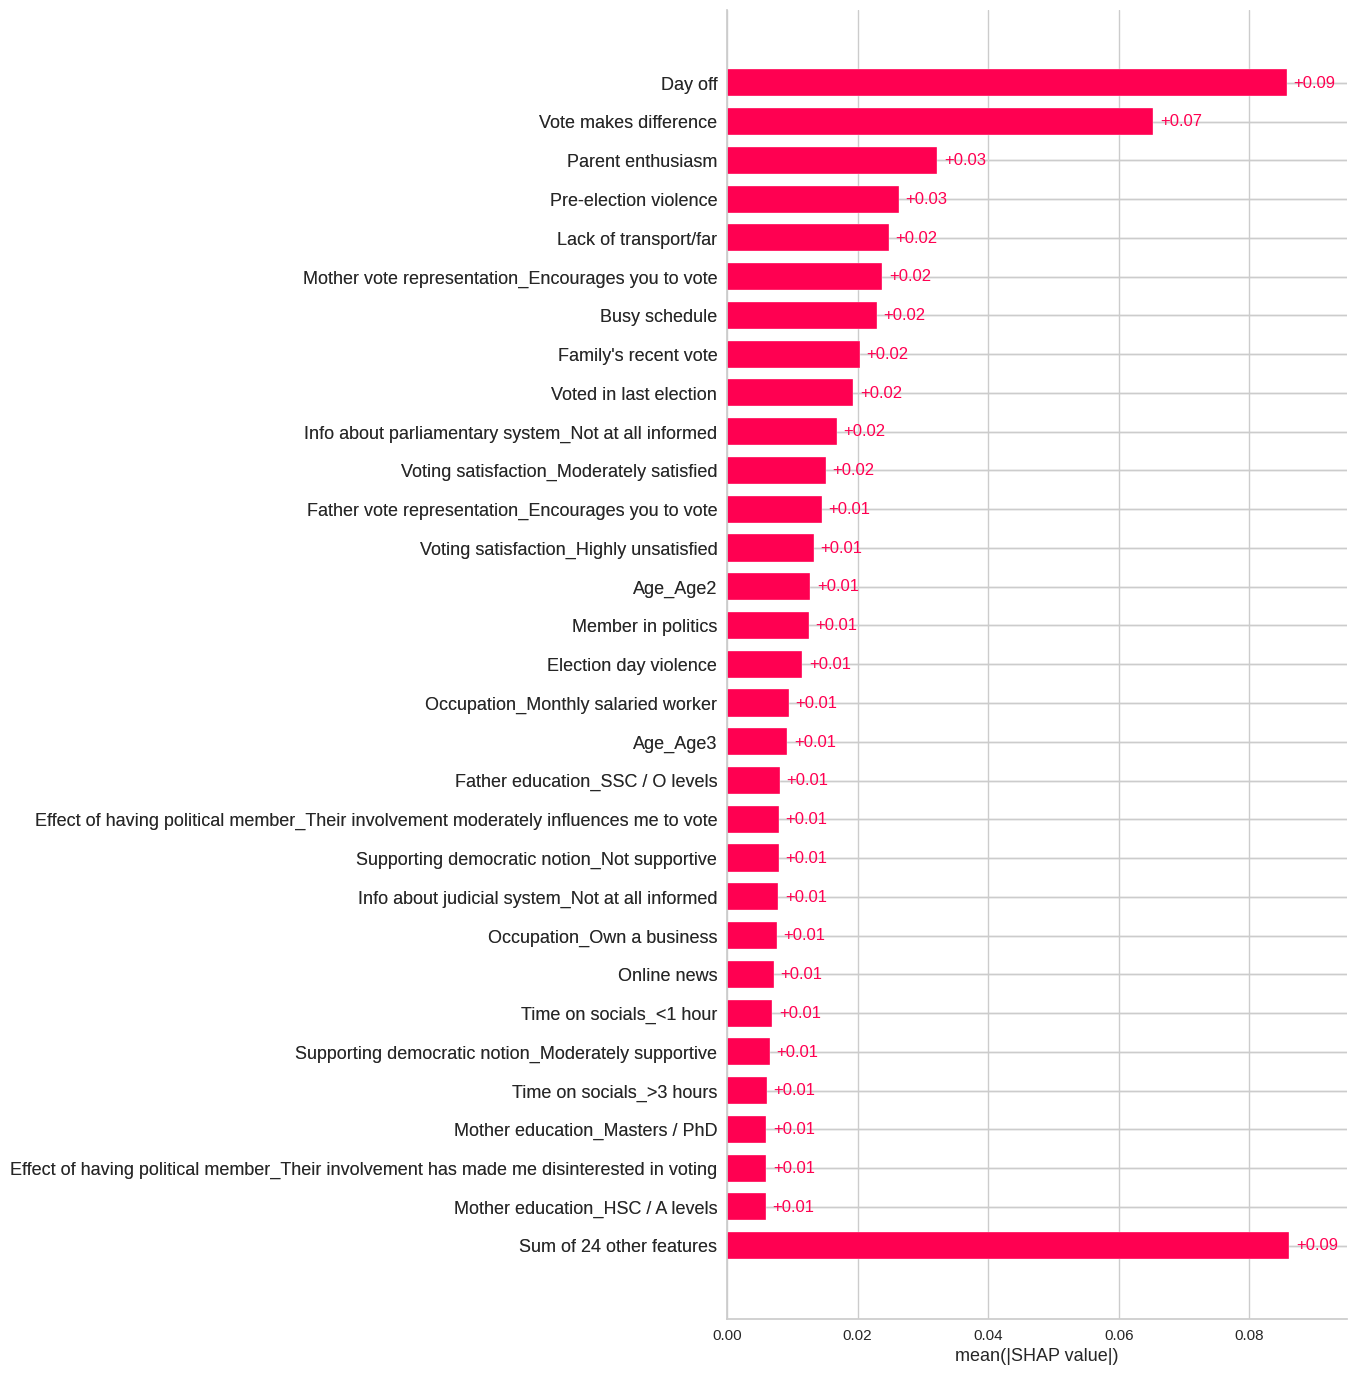

In [ ]:
#shap.plots.bar(shap_values, max_display=X_test_num.shape[1])
shap.plots.bar(shap_values, max_display=31)

In [ ]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test_num.columns)

In [ ]:
shap_df

,Gender,Reside with family,Own house,Financial stability,Parent enthusiasm,Family's recent vote,Member in politics,Newspaper,Social media,Television,Online news,Lack of transport/far,Day off,Busy schedule,Pre-election violence,Election day violence,Current city,Eligible in last election,Voted in last election,Vote makes difference,Occupation_Monthly salaried worker,Occupation_No,Occupation_Own a business,Father education_HSC / A levels,Father education_Masters / PhD,Father education_Primary School,Father education_SSC / O levels,Mother education_HSC / A levels,Mother education_Masters / PhD,Mother education_Primary School,Mother education_SSC / O levels,Time on socials_<1 hour,Time on socials_>3 hours,Time on socials_I don't use social media,Father vote representation_Encourages you to vote,Father vote representation_Neutral,Mother vote representation_Encourages you to vote,Mother vote representation_Neutral,Effect of having political member_Their involvement has made me disinterested in voting,Effect of having political member_Their involvement moderately influences me to vote,Effect of having political member_Their involvement strongly influences me to vote,Political awareness_Not at all aware,Political awareness_Strongly aware,Voting satisfaction_Highly unsatisfied,Voting satisfaction_Moderately satisfied,Voting satisfaction_Never voted before,Info about parliamentary system_Not at all informed,Info about parliamentary system_Strongly informed,Info about judicial system_Not at all informed,Info about judicial system_Strongly informed,Supporting democratic notion_Moderately supportive,Supporting democratic notion_Not supportive,Age_Age2,Age_Age3
0,-0.005645,0.002689,-0.001079,-0.000248,-0.057346,-0.032323,-0.013786,0.006414,0.007823,-0.002630,0.003624,-0.013350,-0.097563,-0.016591,-0.020713,-0.005724,-0.000874,0.000814,-0.020965,-0.051254,-0.007655,-0.000800,-0.003169,-0.007985,0.004170,0.001302,-0.002769,-0.005635,0.012556,-0.002708,-0.001954,-0.004926,-0.005953,0.001925,-0.014550,0.007351,-0.024147,0.002630,-0.000668,-0.013867,4.608811e-03,0.001701,-0.029204,-0.039872,-0.020326,-0.001458,0.012214,-0.015929,0.004676,-0.018648,-6.326897e-03,-0.018878,0.002266,-0.011260
1,-0.008760,0.003980,0.000165,-0.001883,-0.050797,-0.034011,0.002259,-0.009649,0.000591,-0.000045,0.007318,-0.027098,-0.116522,-0.018274,-0.018969,-0.008619,0.005680,0.001242,-0.022438,-0.058893,0.003550,-0.001832,-0.005167,-0.007730,-0.002480,0.001073,-0.003447,-0.005218,-0.000998,-0.002568,0.023007,-0.005538,-0.007919,0.001970,-0.025328,0.003583,-0.032717,-0.003786,-0.000358,-0.012858,2.923764e-03,-0.002886,0.004024,0.005994,-0.019691,0.000163,-0.029360,0.002395,-0.017330,0.001819,1.122221e-02,0.007118,0.009306,0.005758
2,-0.000879,-0.001536,0.008263,-0.004221,0.020582,0.011201,0.015884,-0.001601,-0.015603,-0.017445,-0.015805,-0.015010,-0.075121,-0.019381,-0.020013,-0.008027,0.000347,0.000879,-0.016061,-0.047722,0.008901,0.000692,-0.003262,-0.001737,0.000957,-0.029690,-0.004754,0.000840,0.008016,0.016138,-0.001417,0.067063,-0.009632,0.001740,0.008453,-0.008217,-0.009846,0.000343,0.002497,-0.004079,-6.972064e-04,0.004652,0.002665,0.007620,-0.007981,-0.006012,0.012163,-0.002458,0.001696,-0.026280,-1.972686e-03,-0.014193,-0.000222,0.005886
3,-0.006292,0.002059,-0.002219,-0.000421,-0.059590,-0.035342,-0.008419,0.002455,-0.001836,0.003387,0.002610,-0.017292,-0.086059,-0.016651,-0.011253,-0.003886,-0.001271,0.001471,-0.025253,-0.051673,0.001961,-0.000156,-0.004431,-0.008313,-0.001321,0.001238,-0.003337,0.011020,-0.001459,-0.001605,-0.002148,0.040743,-0.006254,0.002083,-0.019915,0.003994,-0.028150,-0.003990,-0.002162,-0.006169,5.133761e-03,0.002047,0.002797,0.003151,-0.016555,-0.002062,0.011052,0.002475,-0.021719,0.001498,-4.757925e-03,-0.040696,0.001324,-0.033225
4,-0.002488,-0.007480,0.006360,0.001098,0.028732,0.013609,0.022519,0.004268,0.007003,-0.000602,0.006452,-0.021633,-0.110562,-0.027191,-0.021855,-0.010807,0.005675,0.001495,-0.019145,-0.062624,0.008781,-0.

MEAN ABSOLUTE SHAP-VALUES

In [ ]:
absolute_df_shap = shap_df.abs()
mean_values_shap = absolute_df_shap.mean()

sorted_means_shap = mean_values_shap.sort_values(ascending=False)

ranked_df_shap = sorted_means_shap.reset_index()
ranked_df_shap.columns = ['Feature', 'Mean Absolute Value']

pd.options.display.max_colwidth = None
ranked_df_shap

,Feature,Mean Absolute Value
0,Day off,0.085714
1,Vote makes difference,0.065319
2,Parent enthusiasm,0.032242
3,Pre-election violence,0.026342
4,Lack of transport/far,0.024787
5,Mother vote representation_Encourages you to vote,0.023813
6,Busy schedule,0.022992
7,Family's recent vote,0.020345
8,Voted in last election,0.019368
9,Info about parliamentary system_Not at all informed,0.016842


In [ ]:
mean_values_shap_1 = shap_df.mean()

sorted_means_shap_1 = mean_values_shap_1.sort_values(ascending=False)

ranked_df_shap_1 = sorted_means_shap_1.reset_index()
ranked_df_shap_1.columns = ['Feature', 'Mean Value']

pd.options.display.max_colwidth = None
ranked_df_shap_1

,Feature,Mean Value
0,Day off,0.003597
1,Lack of transport/far,0.002742
2,Member in politics,0.001747
3,Pre-election violence,0.001121
4,Vote makes difference,0.001041
5,Busy schedule,0.001038
6,Mother education_Masters / PhD,0.000833
7,Online news,0.000660
8,Father vote representation_Neutral,0.000594
9,Current city,0.000457


# Comparison of SHAP and MLP

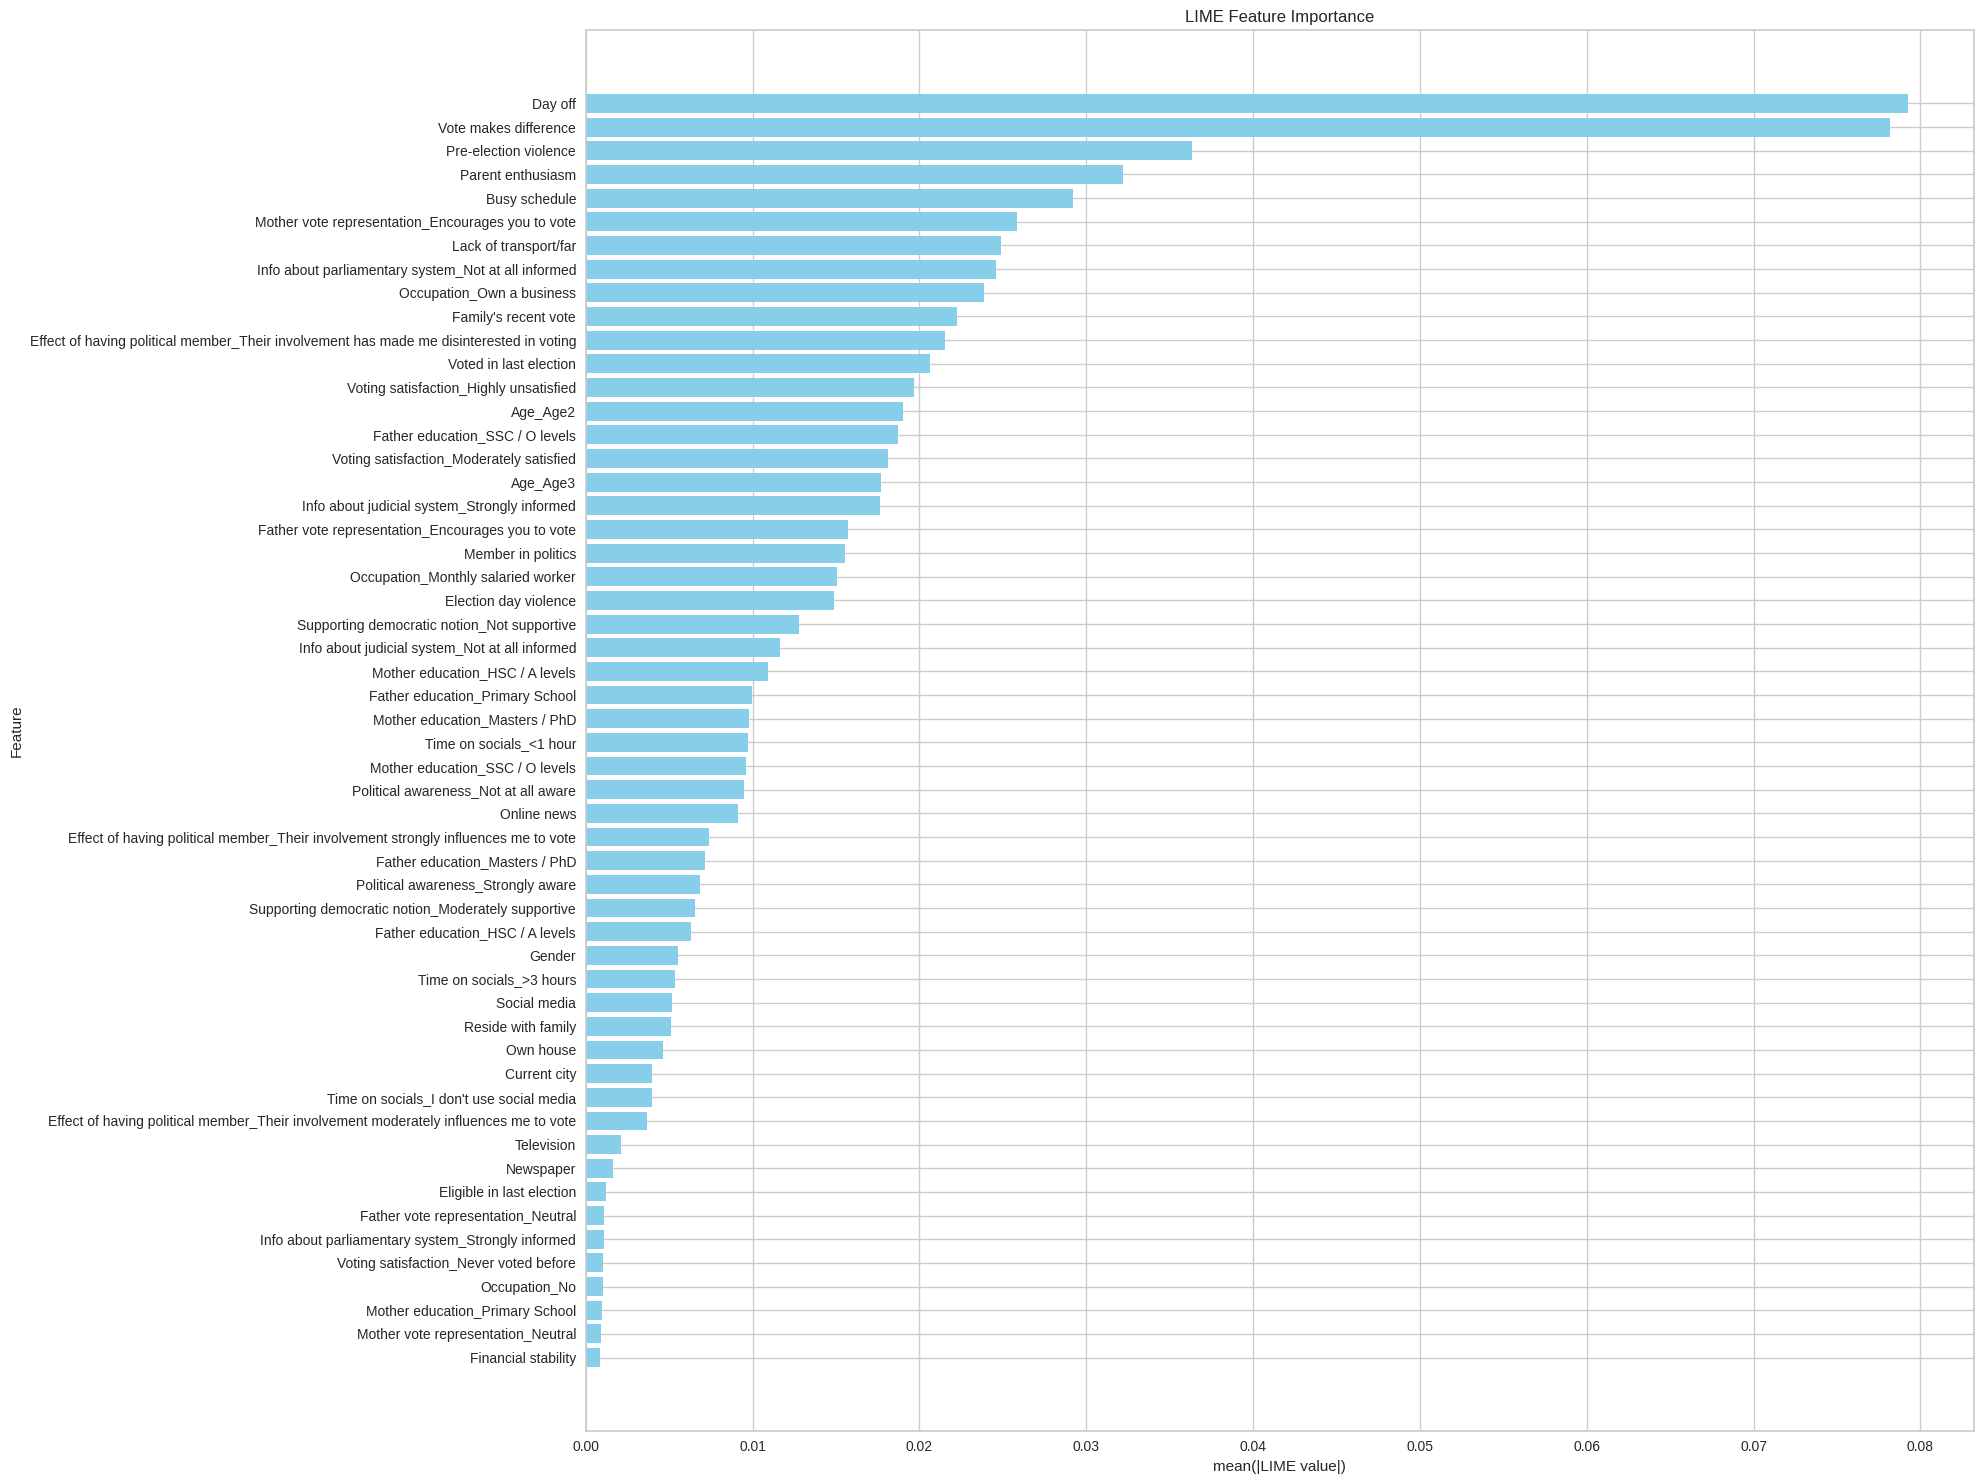

In [ ]:
lime_df_sorted = ranked_df.sort_values(by='Mean Absolute Value', ascending=False)

# Plot the bar chart
plt.figure(figsize=(20, 15))
plt.barh(lime_df_sorted['Feature'], lime_df_sorted['Mean Absolute Value'], color='skyblue')
plt.xlabel('mean(|LIME value|)')
plt.ylabel('Feature')
plt.title('LIME Feature Importance')
plt.gca().invert_yaxis()  # Invert the y-axis to have the largest mean at the top
plt.tight_layout()
plt.show()

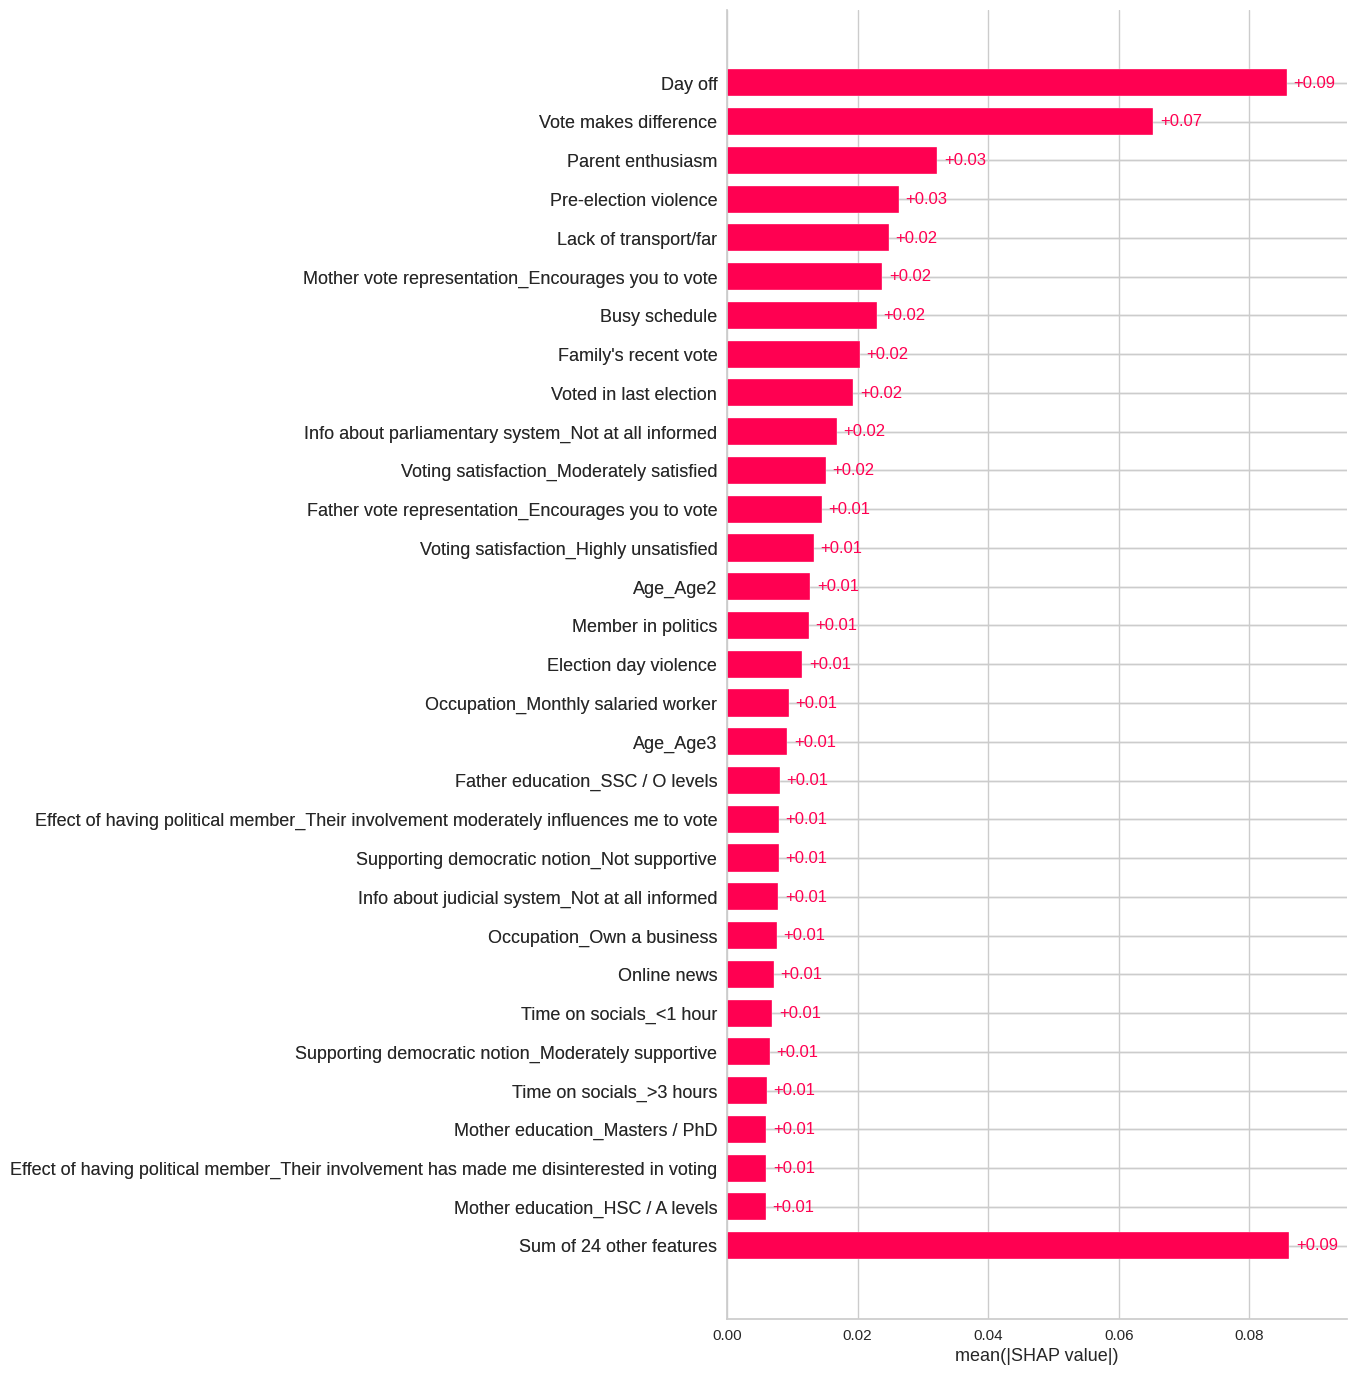

In [ ]:
#shap.plots.bar(shap_values, max_display=X_test_num.shape[1])
shap.plots.bar(shap_values, max_display=31)

Rank of Features according to ABSOLUTE MEAN VALUES

In [ ]:
rank = range(1, max(len(ranked_df), len(ranked_df_shap)) + 1)

# Create a new DataFrame with ranks and sorted feature names
combined_df1 = pd.DataFrame({
    'Rank': rank,
    'LIME Features': ranked_df['Feature'].tolist(),
    'SHAP Features': ranked_df_shap['Feature'].tolist()
})

# Display the resulting DataFrame
pd.options.display.max_colwidth = None
combined_df1

,Rank,LIME Features,SHAP Features
0,1,Day off,Day off
1,2,Vote makes difference,Vote makes difference
2,3,Pre-election violence,Parent enthusiasm
3,4,Parent enthusiasm,Pre-election violence
4,5,Busy schedule,Lack of transport/far
5,6,Mother vote representation_Encourages you to vote,Mother vote representation_Encourages you to vote
6,7,Lack of transport/far,Busy schedule
7,8,Info about parliamentary system_Not at all informed,Family's recent vote
8,9,Occupation_Own a business,Voted in last election
9,10,Family's recent vote,Info about parliamentary system_Not at all informed


# Comparison of Correlation, LIME values, and SHAP values

In [ ]:
correlation_table.rename(columns={"Correlation with Prediction": "Correlation"}, inplace=True)
df_lime = ranked_df.copy()
df_lime.rename(columns={"Mean Absolute Value": "LIME_Mean"}, inplace=True)
df_shap = ranked_df_shap.copy()
df_shap.rename(columns={"Mean Absolute Value": "SHAP_Mean"}, inplace=True)

combined_df = correlation_table.merge(df_lime, on="Feature").merge(df_shap, on="Feature")

combined_df.sort_values(by="Feature", inplace=True)

combined_df.reset_index(drop=True, inplace=True)

combined_df

,Feature,Correlation,LIME_Mean,SHAP_Mean
0,Age_Age2,0.050479,0.019013,0.012769
1,Age_Age3,-0.054327,0.017699,0.009234
2,Busy schedule,0.447591,0.029189,0.022992
3,Current city,-0.052862,0.003998,0.004378
4,Day off,0.715570,0.079249,0.085714
5,Effect of having political member_Their involvement has made me disinterested in voting,-0.286975,0.021554,0.006039
6,Effect of having political member_Their involvement moderately influences me to vote,0.183241,0.003666,0.007959
7,Effect of having political member_Their involvement strongly influences me to vote,0.243048,0.007403,0.002965
8,Election day violence,0.265409,0.014903,0.011548
9,Eligible in last election,-0.078175,0.001190,0.001374


---
# **THE CODES BELOW ARE NOT USED**


---



# PCA and TSNE on the WILL VOTE & WILL NOT VOTE datasets

WILL NOT VOTE

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = combined_dataset_will_not_vote.drop(['Predictions'], axis=1)  # Features only

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print(pca.explained_variance_ratio_)

[0.09103005 0.08636591]


In [ ]:
#principal_df['PC1'] # First principal component

In [ ]:
#principal_df['PC2'] # Second principal component

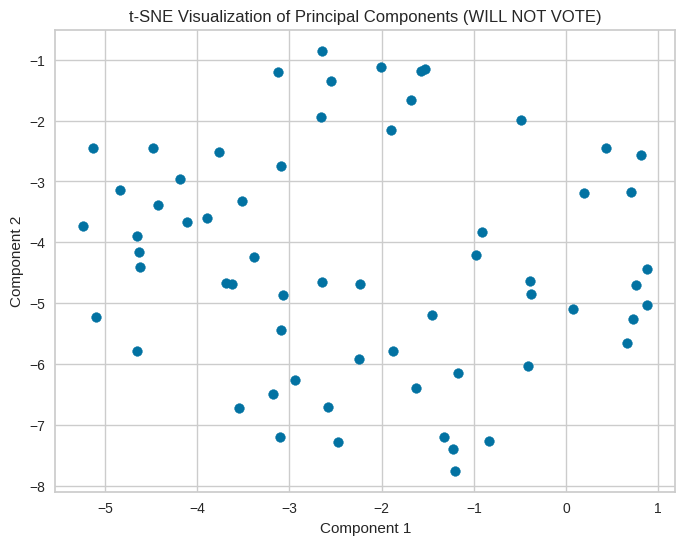

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(principal_df)


plt.figure(figsize=(8, 6))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1])
plt.title('t-SNE Visualization of Principal Components (WILL NOT VOTE)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

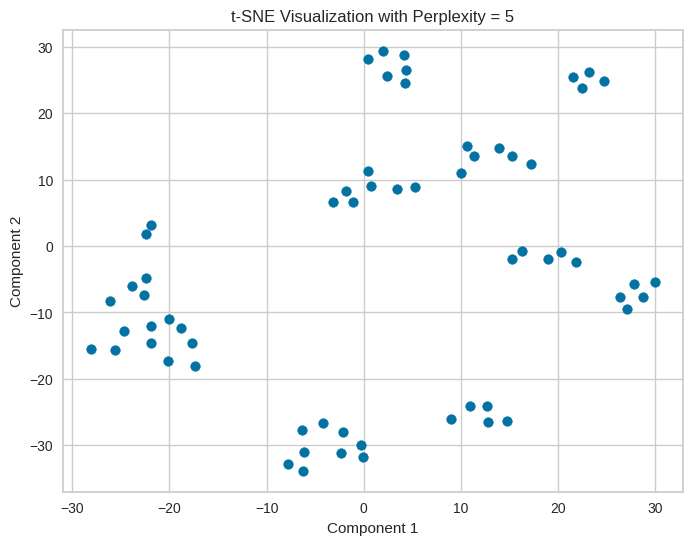

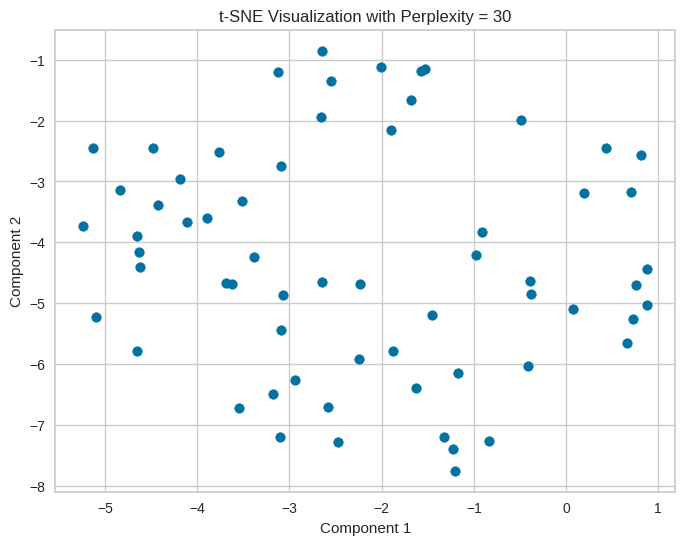

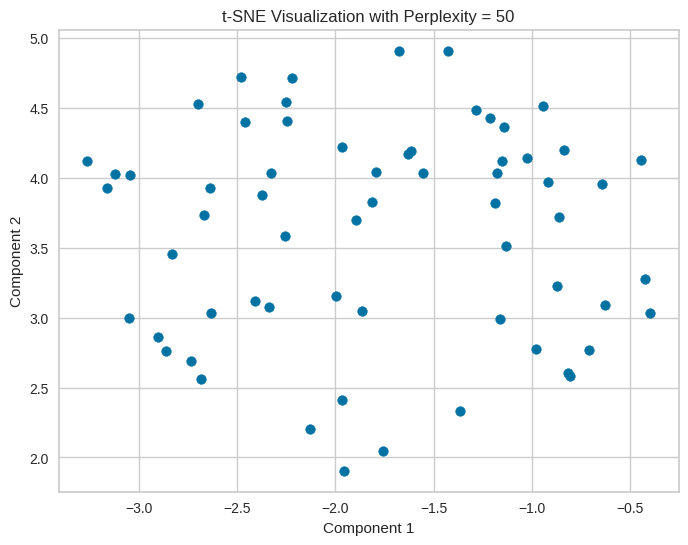

In [ ]:
from sklearn.manifold import TSNE
perplexities = [5, 30, 50] # Trying a range of values

for perplexity in perplexities:
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    tsne_components = tsne.fit_transform(principal_df)

    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_components[:, 0], tsne_components[:, 1])
    plt.title(f't-SNE Visualization with Perplexity = {perplexity}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

WILL VOTE:

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X1 = combined_dataset_will_vote.drop(['Predictions'], axis=1)  # Features only

pca1 = PCA(n_components=2)
principal_components1 = pca1.fit_transform(X1)

principal_df1 = pd.DataFrame(data=principal_components1, columns=['PC1', 'PC2'])

print(pca1.explained_variance_ratio_)

[0.13429644 0.06936714]


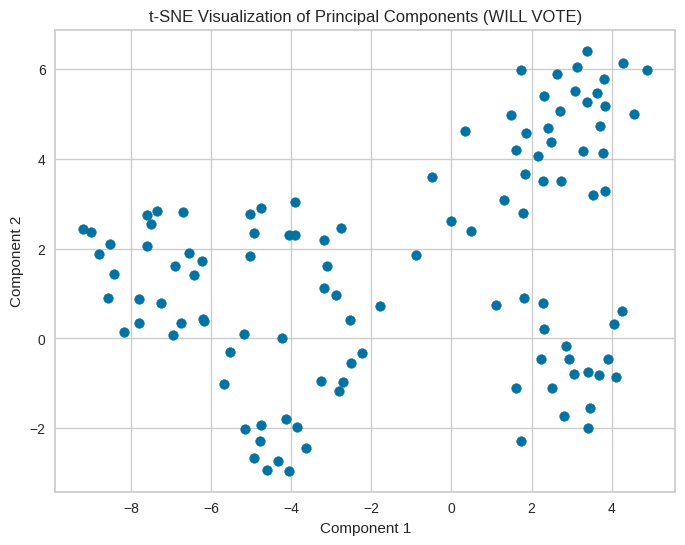

In [ ]:
from sklearn.manifold import TSNE

tsne1 = TSNE(n_components=2, random_state=42)
tsne_components1 = tsne1.fit_transform(principal_df1)


plt.figure(figsize=(8, 6))
plt.scatter(tsne_components1[:, 0], tsne_components1[:, 1])
plt.title('t-SNE Visualization of Principal Components (WILL VOTE)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

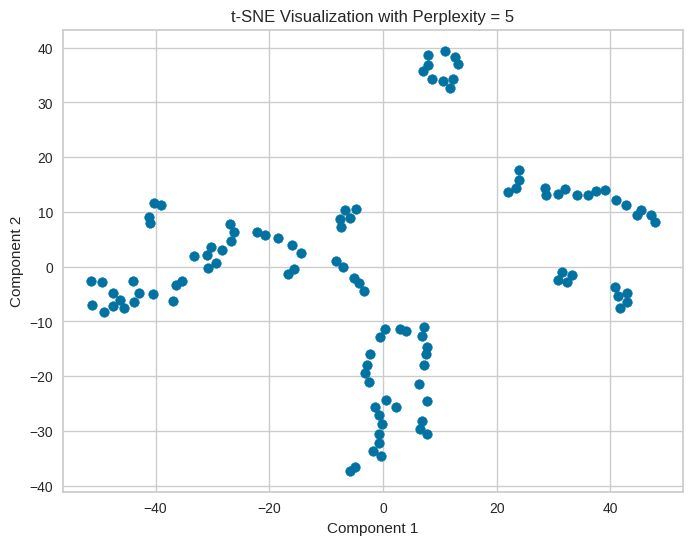

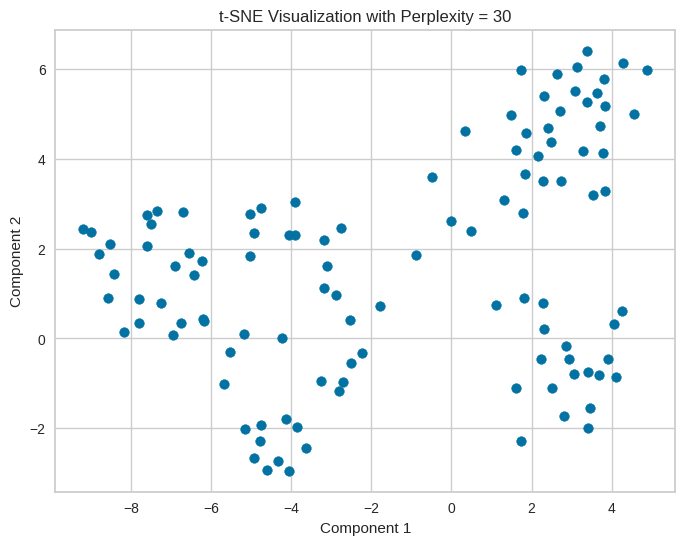

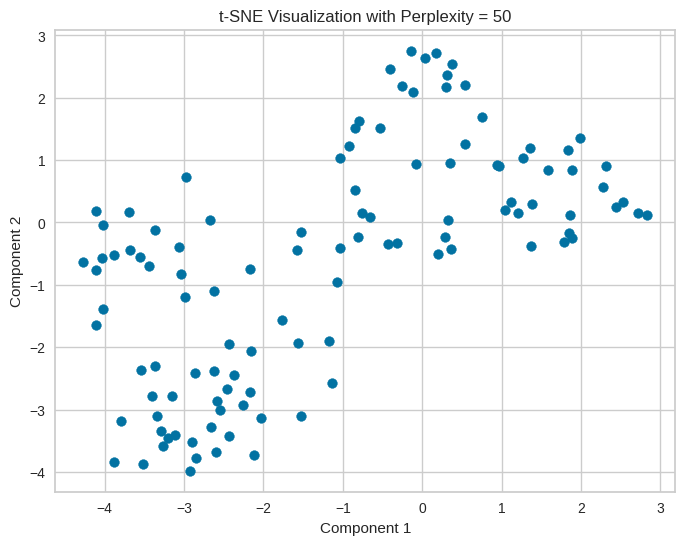

In [ ]:
from sklearn.manifold import TSNE
perplexities = [5, 30, 50]  # Trying a range of values

for perplexity in perplexities:
    tsne1 = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    tsne_components1 = tsne1.fit_transform(principal_df1)

    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_components1[:, 0], tsne_components1[:, 1])
    plt.title(f't-SNE Visualization with Perplexity = {perplexity}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

# SHAP on Ensemble model

In [ ]:
import shap
explainer1 = shap.DeepExplainer(ensemble_model, [y_pred_xgb_prob, y_pred_mlp_prob])
shap_values1 = explainer1.shap_values([y_pred_xgb_prob, y_pred_mlp_prob])

/usr/local/lib/python3.10/dist-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


ValueError: could not broadcast input array from shape (174,1) into shape (1,1)